# 0. les biblios

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Charger environmental_monthly.csv

In [2]:
# Charger les données
df = pd.read_csv("environmental_monthly.csv")

In [3]:
# 1. Dimensions et types de colonnes
print("Dimensions :", df.shape)
print("\nTypes de colonnes :")
df.info()

Dimensions : (4994, 11)

Types de colonnes :
<class 'pandas.DataFrame'>
RangeIndex: 4994 entries, 0 to 4993
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   site_code                  4994 non-null   str    
 1   reporting_month            4994 non-null   str    
 2   mean_temperature_c         4994 non-null   str    
 3   rainfall_mm                4994 non-null   str    
 4   mean_humidity_pct          4994 non-null   str    
 5   vegetation_cover_pct       4984 non-null   float64
 6   habitat_disturbance_index  4994 non-null   float64
 7   pesticide_index            4979 non-null   float64
 8   land_use_category          4994 non-null   str    
 9   weather_exception_code     204 non-null    str    
 10  data_completeness_pct      4994 non-null   float64
dtypes: float64(4), str(7)
memory usage: 429.3 KB


In [4]:
# 2. Échantillon des données
print("\nPremières lignes :")
display(df.head())


Premières lignes :


,site_code,reporting_month,mean_temperature_c,rainfall_mm,mean_humidity_pct,vegetation_cover_pct,habitat_disturbance_index,pesticide_index,land_use_category,weather_exception_code,data_completeness_pct
0,KNT-KES,2019-01-01,25.25,95.0,74.4,69.7,25.9,31.6,karst_habitat,NaN,98.6
1,KNT-KES,2019-02-01,25.72,78.5,67.3,64.1,23.5,19.4,karst_habitat,NaN,90.4
2,KNT-KES,2019-03-01,25.8,100.4,67.0,62.8,24.6,18.0,karst_habitat,NaN,100.0
3,KNT-KES,2019-04-01,26.68,189.2,68.8,68.5,19.0,21.7,karst_habitat,NaN,96.0
4,KNT-KES,2019-05-01,26.87,198.9,75.9,74.3,21.1,17.1,karst_habitat,NaN,93.9


- 4994 lignes et 11 colonnes.
- Une ligne = un relevé environnemental mensuel pour un site (`site_code` + `reporting_month`).
- Presque toutes les colonnes sont en `object` alors qu'elles devraient être numériques ou date : c'est déjà le signe de formats incohérents.

# 2. Doublons

### a- Doublons de lignes

In [5]:
print("Nombre de lignes strictement dupliquées :", df.duplicated().sum())
display(df[df.duplicated(keep=False)].sort_values(['site_code', 'reporting_month']))

Nombre de lignes strictement dupliquées : 2


,site_code,reporting_month,mean_temperature_c,rainfall_mm,mean_humidity_pct,vegetation_cover_pct,habitat_disturbance_index,pesticide_index,land_use_category,weather_exception_code,data_completeness_pct
3489,AVL-NMQ,2023-10-01,25.88,203.0,81.6,80.8,23.3,38.1,durian_orchard,NaN,100.0
4993,AVL-NMQ,2023-10-01,25.88,203.0,81.6,80.8,23.3,38.1,durian_orchard,NaN,100.0
3490,AVL-NMQ,2023-11-01,25.48,241.4,80.2,75.1,22.8,24.6,durian_orchard,NaN,92.1
4992,AVL-NMQ,2023-11-01,25.48,241.4,80.2,75.1,22.8,24.6,durian_orchard,NaN,92.1


### b- Doublons sur la clé métier (site_code + reporting_month)

Le vrai identifiant de ce jeu de données n'est pas une colonne unique : c'est le couple **(site, mois)**.
Un même site ne peut pas avoir deux relevés pour le même mois.

In [6]:
cle = ['site_code', 'reporting_month']
print("Couples (site_code, reporting_month) dupliqués :", df.duplicated(subset=cle).sum())
display(df[df.duplicated(subset=cle, keep=False)].sort_values(cle))

Couples (site_code, reporting_month) dupliqués : 2


,site_code,reporting_month,mean_temperature_c,rainfall_mm,mean_humidity_pct,vegetation_cover_pct,habitat_disturbance_index,pesticide_index,land_use_category,weather_exception_code,data_completeness_pct
3489,AVL-NMQ,2023-10-01,25.88,203.0,81.6,80.8,23.3,38.1,durian_orchard,NaN,100.0
4993,AVL-NMQ,2023-10-01,25.88,203.0,81.6,80.8,23.3,38.1,durian_orchard,NaN,100.0
3490,AVL-NMQ,2023-11-01,25.48,241.4,80.2,75.1,22.8,24.6,durian_orchard,NaN,92.1
4992,AVL-NMQ,2023-11-01,25.48,241.4,80.2,75.1,22.8,24.6,durian_orchard,NaN,92.1


- Solution

In [7]:
# On supprime les doublons stricts puis les doublons de clé métier (on garde la 1ère occurrence)
df = df.drop_duplicates(keep='first')
df = df.drop_duplicates(subset=cle, keep='first')

# Vérification
print("Nombre de lignes après suppression :", df.shape[0])
print("Doublons stricts restants :", df.duplicated().sum())
print("Doublons de clé restants :", df.duplicated(subset=cle).sum())

Nombre de lignes après suppression : 4992
Doublons stricts restants : 0
Doublons de clé restants : 0


### c- Doublons de colonnes

In [8]:
# 1. Vérifier si des noms de colonnes sont strictement identiques
noms_doublons = df.columns[df.columns.duplicated()]
print("Noms de colonnes en double :", noms_doublons.tolist())

# 2. Vérifier si le contenu de certaines colonnes est 100% identique
contenu_doublons = df.columns[df.T.duplicated()]
print("Colonnes avec un contenu dupliqué :", contenu_doublons.tolist())

Noms de colonnes en double : []
Colonnes avec un contenu dupliqué : []


- Aucune colonne redondante au sens strict.
- On vérifiera plus bas la redondance *fonctionnelle* (ex : `site_code` → `land_use_category`) et la colinéarité via la matrice de corrélation.

# 3. Formats incohérents

### Les types de chaque colonne :

In [9]:
print(df.dtypes)

site_code                        str
reporting_month                  str
mean_temperature_c               str
rainfall_mm                      str
mean_humidity_pct                str
vegetation_cover_pct         float64
habitat_disturbance_index    float64
pesticide_index              float64
land_use_category                str
weather_exception_code           str
data_completeness_pct        float64
dtype: object


### - Vérifier le format de site_code (catégorielle)

In [10]:
print("Valeurs uniques :", df['site_code'].nunique())
print("Formats structurels :", df['site_code'].str.replace(r'[A-Z0-9]+', 'X', regex=True).unique())
print(df['site_code'].str.extract(r'^([A-Z]+)-')[0].value_counts())
print("Manquants :", df['site_code'].isna().sum())

Valeurs uniques : 64
Formats structurels : <StringArray>
['X-X']
Length: 1, dtype: str
0
KNT    1716
AVL    1716
TMB    1560
Name: count, dtype: int64
Manquants : 0


→ Format homogène `XXX-XXX` (64 sites répartis sur 3 régions : AVL, KNT, TMB). Rien à corriger.

### - Vérifier le format de reporting_month (date) <--->

In [11]:
# On remplace tous les chiffres par 9 pour voir les "patrons" de format présents
print("Formats bruts rencontrés :", df['reporting_month'].str.replace(r'\d', '9', regex=True).unique())

dates = pd.to_datetime(df['reporting_month'], errors='coerce')
print("Valeurs non convertibles :", dates.isna().sum() - df['reporting_month'].isna().sum())

Formats bruts rencontrés : <StringArray>
['9999-99-99']
Length: 1, dtype: str
Valeurs non convertibles : 0


- Solution

In [12]:
# Conversion en vrai type datetime (format ISO homogène ici)
df['reporting_month'] = pd.to_datetime(df['reporting_month'], format='mixed', errors='coerce')

# Vérification
print("Type de la colonne :", df['reporting_month'].dtype)
print("Dates non convertibles :", df['reporting_month'].isna().sum())
print("Période couverte :", df['reporting_month'].min(), "->", df['reporting_month'].max())
print("Nombre de mois par site :")
print(df.groupby('site_code').size().value_counts())

Type de la colonne : datetime64[us]
Dates non convertibles : 0
Période couverte : 2019-01-01 00:00:00 -> 2025-06-01 00:00:00
Nombre de mois par site :
78    64
Name: count, dtype: int64


### - Vérifier le format des colonnes numériques <--->

In [13]:
cols_num = ['mean_temperature_c', 'rainfall_mm', 'mean_humidity_pct',
            'vegetation_cover_pct', 'habitat_disturbance_index',
            'pesticide_index', 'data_completeness_pct']

for col in cols_num:
    s = df[col]
    non_num = s[pd.to_numeric(s, errors='coerce').isna() & s.notna()]
    print(col, "| non convertibles :", len(non_num), "| exemples :", non_num.unique()[:8])

mean_temperature_c | non convertibles : 40 | exemples : <StringArray>
['23,81', '26,34', '29,35', '26,63', '24,65', '26,56', '25.86 C', '23.3 C']
Length: 8, dtype: str
rainfall_mm | non convertibles : 50 | exemples : <StringArray>
['102.7 mm',     '75,5', '251.3 mm',  '67.9 mm',  '29.5 mm',  '91.9 mm',
 '210.9 mm', '216.7 mm']
Length: 8, dtype: str
mean_humidity_pct | non convertibles : 10 | exemples : <StringArray>
['74,8', '64,7', '73,5', '83,2', '70,7', '87,4', '68,8', '80,0']
Length: 8, dtype: str
vegetation_cover_pct | non convertibles : 0 | exemples : []
habitat_disturbance_index | non convertibles : 0 | exemples : []
pesticide_index | non convertibles : 0 | exemples : []
data_completeness_pct | non convertibles : 0 | exemples : []


**Constat :** trois problèmes se cumulent sur les mêmes colonnes :
- **séparateur décimal variable** : `23,81` (virgule française) au lieu de `23.81`
- **unité collée à la valeur** : `25.86 C`, `102.7 mm`
- résultat : pandas a typé toute la colonne en texte.

Comme le cours le recommande, on **garde une seule unité par colonne** (déjà indiquée dans le nom : `_c`, `_mm`, `_pct`) et on convertit tout le reste.

- Solution

In [14]:
for col in cols_num:
    df[col] = (df[col].astype(str)
                      .str.replace(r'\s*(mm|C|%)$', '', regex=True)   # on enlève l'unité collée
                      .str.replace(',', '.', regex=False)             # virgule -> point
                      .str.strip()
                      .replace({'nan': np.nan, '': np.nan}))
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Vérification
print(df[cols_num].dtypes)
print("\nValeurs encore non numériques :")
print(df[cols_num].isna().sum())

mean_temperature_c           float64
rainfall_mm                  float64
mean_humidity_pct            float64
vegetation_cover_pct         float64
habitat_disturbance_index    float64
pesticide_index              float64
data_completeness_pct        float64
dtype: object

Valeurs encore non numériques :
mean_temperature_c            0
rainfall_mm                   0
mean_humidity_pct             0
vegetation_cover_pct         10
habitat_disturbance_index     0
pesticide_index              15
data_completeness_pct         0
dtype: int64


### - Vérifier le format de land_use_category (catégorielle) <--->

In [15]:
print(df['land_use_category'].value_counts(dropna=False))
print("Nombre de catégories brutes :", df['land_use_category'].nunique())

land_use_category
mixed_forest         1481
coastal_habitat       780
durian_orchard        777
karst_habitat         697
research_site         467
mixed_agriculture     388
protected_forest      234
degraded_land         153
Karst_Habitat           4
DEGRADED_LAND           2
DURIAN_ORCHARD          2
Degraded_Land           1
KARST_HABITAT           1
Research_Site           1
Durian_Orchard          1
MIXED_AGRICULTURE       1
Mixed_Agriculture       1
Mixed_Forest            1
Name: count, dtype: int64
Nombre de catégories brutes : 18


**Constat :** 18 catégories alors qu'il n'y en a que 8 réellement. Le même objet est écrit de 3 façons :
`karst_habitat`, `Karst_Habitat`, `KARST_HABITAT`.

Bonne pratique du cours : identifier les différents noms d'un même objet → choisir le label le plus adapté → remplacer le reste.
Ici on choisit le format `snake_case` en minuscules (le plus fréquent).

- Solution

In [16]:
df['land_use_category'] = df['land_use_category'].str.strip().str.lower()

# Vérification
print(df['land_use_category'].value_counts())
print("Nombre de catégories après nettoyage :", df['land_use_category'].nunique())

land_use_category
mixed_forest         1482
durian_orchard        780
coastal_habitat       780
karst_habitat         702
research_site         468
mixed_agriculture     390
protected_forest      234
degraded_land         156
Name: count, dtype: int64
Nombre de catégories après nettoyage : 8


In [17]:
# Cohérence : un site doit toujours avoir le même type d'occupation du sol
print("Sites ayant plusieurs land_use_category :",
      (df.groupby('site_code')['land_use_category'].nunique() > 1).sum())

Sites ayant plusieurs land_use_category : 0


→ Chaque site n'a qu'une seule catégorie d'occupation du sol : la correspondance `site_code` → `land_use_category` est parfaite.
On conserve quand même les deux colonnes (identifiant du lieu vs. caractéristique écologique), comme information conceptuellement distincte.

### - Vérifier le format de weather_exception_code (catégorielle)

In [18]:
print(df['weather_exception_code'].value_counts(dropna=False))
print("Manquants :", df['weather_exception_code'].isna().sum())

weather_exception_code
NaN           4788
HEAVY_RAIN     112
DRY_SPELL       92
Name: count, dtype: int64
Manquants : 4788


# 4. Valeurs manquantes

### a. Constat du problème

In [19]:
print("Valeurs manquantes par colonne :")
print(df.isna().sum())

print("\nPourcentage de manquants par colonne :")
print((df.isna().sum() / len(df) * 100).round(2))

Valeurs manquantes par colonne :
site_code                       0
reporting_month                 0
mean_temperature_c              0
rainfall_mm                     0
mean_humidity_pct               0
vegetation_cover_pct           10
habitat_disturbance_index       0
pesticide_index                15
land_use_category               0
weather_exception_code       4788
data_completeness_pct           0
dtype: int64

Pourcentage de manquants par colonne :
site_code                     0.00
reporting_month               0.00
mean_temperature_c            0.00
rainfall_mm                   0.00
mean_humidity_pct             0.00
vegetation_cover_pct          0.20
habitat_disturbance_index     0.00
pesticide_index               0.30
land_use_category             0.00
weather_exception_code       95.91
data_completeness_pct         0.00
dtype: float64


- `weather_exception_code` : ~96% de manquants
- `pesticide_index` : 15 manquants (0.3%)
- `vegetation_cover_pct` : 10 manquants (0.2%)

Les deux cas n'ont rien à voir et se traitent différemment.

### b. weather_exception_code : l'absence d'information EST une information

Hypothèse : ce n'est pas une donnée perdue, c'est un code d'exception météo qui n'est renseigné que
quand le mois est anormal. Un mois "normal" n'a donc pas de code.

In [20]:
# Vérification de l'hypothèse : comparer la pluviométrie selon le code
print(df.groupby('weather_exception_code')['rainfall_mm'].describe())
print("\nMois sans code :")
print(df[df['weather_exception_code'].isna()]['rainfall_mm'].describe())

                        count        mean        std   min      25%     50%  \
weather_exception_code                                                        
DRY_SPELL                92.0   23.676087   9.640612   5.0   16.475   26.85   
HEAVY_RAIN              112.0  255.493750  56.151818  81.1  218.475  265.70   

                            75%    max  
weather_exception_code                  
DRY_SPELL                32.500   35.0  
HEAVY_RAIN              294.225  366.7  

Mois sans code :
count    4788.000000
mean      160.275167
std        72.138219
min        35.100000
25%        97.300000
50%       155.850000
75%       220.325000
max       384.300000
Name: rainfall_mm, dtype: float64


→ Preuve par les données : `DRY_SPELL` = mois très secs (moyenne ~24 mm), `HEAVY_RAIN` = mois très pluvieux
(moyenne ~255 mm), les lignes sans code = régime normal (~160 mm).

Le vide est donc porteur de sens. Comme le dit le cours, « considérer que l'absence d'information est une
information en soi » : on remplace `NaN` par une vraie modalité `NORMAL` plutôt que de supprimer 96% du jeu.

In [21]:
df['weather_exception_code'] = df['weather_exception_code'].fillna('NORMAL')

# Vérification
print(df['weather_exception_code'].value_counts())
print("Manquants restants :", df['weather_exception_code'].isna().sum())

weather_exception_code
NORMAL        4788
HEAVY_RAIN     112
DRY_SPELL       92
Name: count, dtype: int64
Manquants restants : 0


### c. vegetation_cover_pct et pesticide_index : inférence par série temporelle du site

Hypothèse : ces trous sont isolés (1 ou 2 mois par site). Comme chaque site est suivi mois par mois,
la valeur manquante peut être inférée à partir des mois qui l'encadrent **sur le même site**,
plutôt qu'avec une moyenne globale qui écraserait les différences entre sites.

In [22]:
for col in ['vegetation_cover_pct', 'pesticide_index']:
    trous = df[df[col].isna()]
    print(col, "->", len(trous), "trous répartis sur", trous['site_code'].nunique(), "sites")
    display(trous[['site_code', 'reporting_month', col]].head())

vegetation_cover_pct -> 10 trous répartis sur 10 sites


,site_code,reporting_month,vegetation_cover_pct
863,KNT-NNM,2019-06-01,NaN
1858,KNT-VXR,2024-05-01,NaN
1998,KNT-BME,2023-01-01,NaN
2076,KNT-XAC,2023-01-01,NaN
2342,AVL-GRB,2019-03-01,NaN


pesticide_index -> 15 trous répartis sur 12 sites


,site_code,reporting_month,pesticide_index
731,KNT-YRX,2021-06-01,NaN
1437,KNT-DMJ,2021-10-01,NaN
1648,KNT-TLQ,2019-11-01,NaN
1649,KNT-TLQ,2019-12-01,NaN
1807,KNT-VXR,2020-02-01,NaN


- Solution

In [23]:
# On trie par site et par mois, puis on interpole à l'intérieur de chaque site
df = df.sort_values(['site_code', 'reporting_month']).reset_index(drop=True)

for col in ['vegetation_cover_pct', 'pesticide_index']:
    df[col] = df.groupby('site_code')[col].transform(
        lambda s: s.interpolate(limit_direction='both')
    )

# Vérification
print("Valeurs manquantes restantes :")
print(df.isna().sum())

Valeurs manquantes restantes :
site_code                    0
reporting_month              0
mean_temperature_c           0
rainfall_mm                  0
mean_humidity_pct            0
vegetation_cover_pct         0
habitat_disturbance_index    0
pesticide_index              0
land_use_category            0
weather_exception_code       0
data_completeness_pct        0
dtype: int64


Solution

On remplace chaque mois manquant en le calculant à partir du mois d'avant et du mois d'après, du même site uniquement (pour ne jamais mélanger les sites entre eux).

Vérification : on recompte les valeurs manquantes, elles doivent toutes être à 0.

# 5. Gestion des variables catégorielles

### a. Création des variables temporelles

La date seule est difficile à exploiter dans un modèle : on en extrait l'année et le mois,
ce qui permettra ensuite d'observer la saisonnalité.

In [24]:
df['year'] = df['reporting_month'].dt.year
df['month'] = df['reporting_month'].dt.month

display(df.head())

,site_code,reporting_month,mean_temperature_c,rainfall_mm,mean_humidity_pct,vegetation_cover_pct,habitat_disturbance_index,pesticide_index,land_use_category,weather_exception_code,data_completeness_pct,year,month
0,AVL-ABG,2019-01-01,27.28,118.9,69.2,61.1,21.1,39.0,mixed_forest,NORMAL,96.2,2019,1
1,AVL-ABG,2019-02-01,28.78,91.4,67.7,54.9,16.8,42.1,mixed_forest,NORMAL,95.3,2019,2
2,AVL-ABG,2019-03-01,28.70,62.6,73.7,59.2,13.9,37.4,mixed_forest,NORMAL,90.4,2019,3
3,AVL-ABG,2019-04-01,28.64,70.2,68.5,61.8,11.1,32.9,mixed_forest,NORMAL,99.1,2019,4
4,AVL-ABG,2019-05-01,28.66,96.6,71.3,61.6,23.6,38.8,mixed_forest,NORMAL,100.0,2019,5


### b. Variables ordonnées

Aucune variable réellement ordinale ici : `land_use_category` (forêt, verger, karst…) et
`weather_exception_code` (DRY_SPELL / NORMAL / HEAVY_RAIN) n'ont pas de hiérarchie chiffrable
évidente — on les traite donc comme nominales.

Les "notes" (`habitat_disturbance_index`, `pesticide_index`, `data_completeness_pct`) sont déjà
des variables numériques continues, pas des catégories.

### c. Encodage des variables nominales : reporté après le merge

Ce fichier fait partie d'un lot de 6 fichiers qui seront fusionnés ensemble plus tard sur `site_code`
(et `reporting_month` pour ceux qui ont une dimension temporelle). Encoder maintenant créerait un risque :
- des colonnes dummy différentes d'un fichier à l'autre (une catégorie présente ici mais absente ailleurs) ;
- une redondance si une même colonne catégorielle (ex: `land_use_category`) existe dans plusieurs fichiers du lot.

**Décision** : on nettoie et normalise les catégories ici (fait à l'étape 3 : `land_use_category` et
`weather_exception_code` sont déjà propres, sans casse incohérente), mais on **reporte le One-Hot Encoding
au moment du merge final**, une fois tous les fichiers fusionnés, pour avoir un schéma d'encodage unique
et cohérent sur l'ensemble du projet.

In [25]:
# Pas d'encodage ici : on garde les colonnes catégorielles nettoyées telles quelles
df_stats = df.copy()

print(df_stats.dtypes)
display(df_stats.head())

site_code                               str
reporting_month              datetime64[us]
mean_temperature_c                  float64
rainfall_mm                         float64
mean_humidity_pct                   float64
vegetation_cover_pct                float64
habitat_disturbance_index           float64
pesticide_index                     float64
land_use_category                       str
weather_exception_code                  str
data_completeness_pct               float64
year                                  int32
month                                 int32
dtype: object


,site_code,reporting_month,mean_temperature_c,rainfall_mm,mean_humidity_pct,vegetation_cover_pct,habitat_disturbance_index,pesticide_index,land_use_category,weather_exception_code,data_completeness_pct,year,month
0,AVL-ABG,2019-01-01,27.28,118.9,69.2,61.1,21.1,39.0,mixed_forest,NORMAL,96.2,2019,1
1,AVL-ABG,2019-02-01,28.78,91.4,67.7,54.9,16.8,42.1,mixed_forest,NORMAL,95.3,2019,2
2,AVL-ABG,2019-03-01,28.70,62.6,73.7,59.2,13.9,37.4,mixed_forest,NORMAL,90.4,2019,3
3,AVL-ABG,2019-04-01,28.64,70.2,68.5,61.8,11.1,32.9,mixed_forest,NORMAL,99.1,2019,4
4,AVL-ABG,2019-05-01,28.66,96.6,71.3,61.6,23.6,38.8,mixed_forest,NORMAL,100.0,2019,5


# 6. Voir les outliers (colonnes numériques)

In [26]:
# Tableau statistique pour traquer les valeurs aberrantes
display(df_stats[cols_num].describe().T)

,count,mean,std,min,25%,50%,75%,max
mean_temperature_c,4992.0,26.377073,1.672062,21.3,25.19,26.35,27.6125,32.0
rainfall_mm,4992.0,159.894030,74.901939,5.0,95.70,156.25,221.7000,384.3
mean_humidity_pct,4992.0,75.841847,7.248342,56.7,70.30,75.90,81.5000,96.4
vegetation_cover_pct,4992.0,61.006080,14.001057,15.0,52.70,62.30,70.9000,98.0
habitat_disturbance_index,4992.0,30.364423,16.358109,0.0,17.90,29.40,41.4000,86.8
pesticide_index,4992.0,25.018970,16.271040,0.0,11.60,25.20,37.5000,77.3
data_completeness_pct,4992.0,95.961819,2.817944,85.5,94.00,96.15,98.2000,100.0


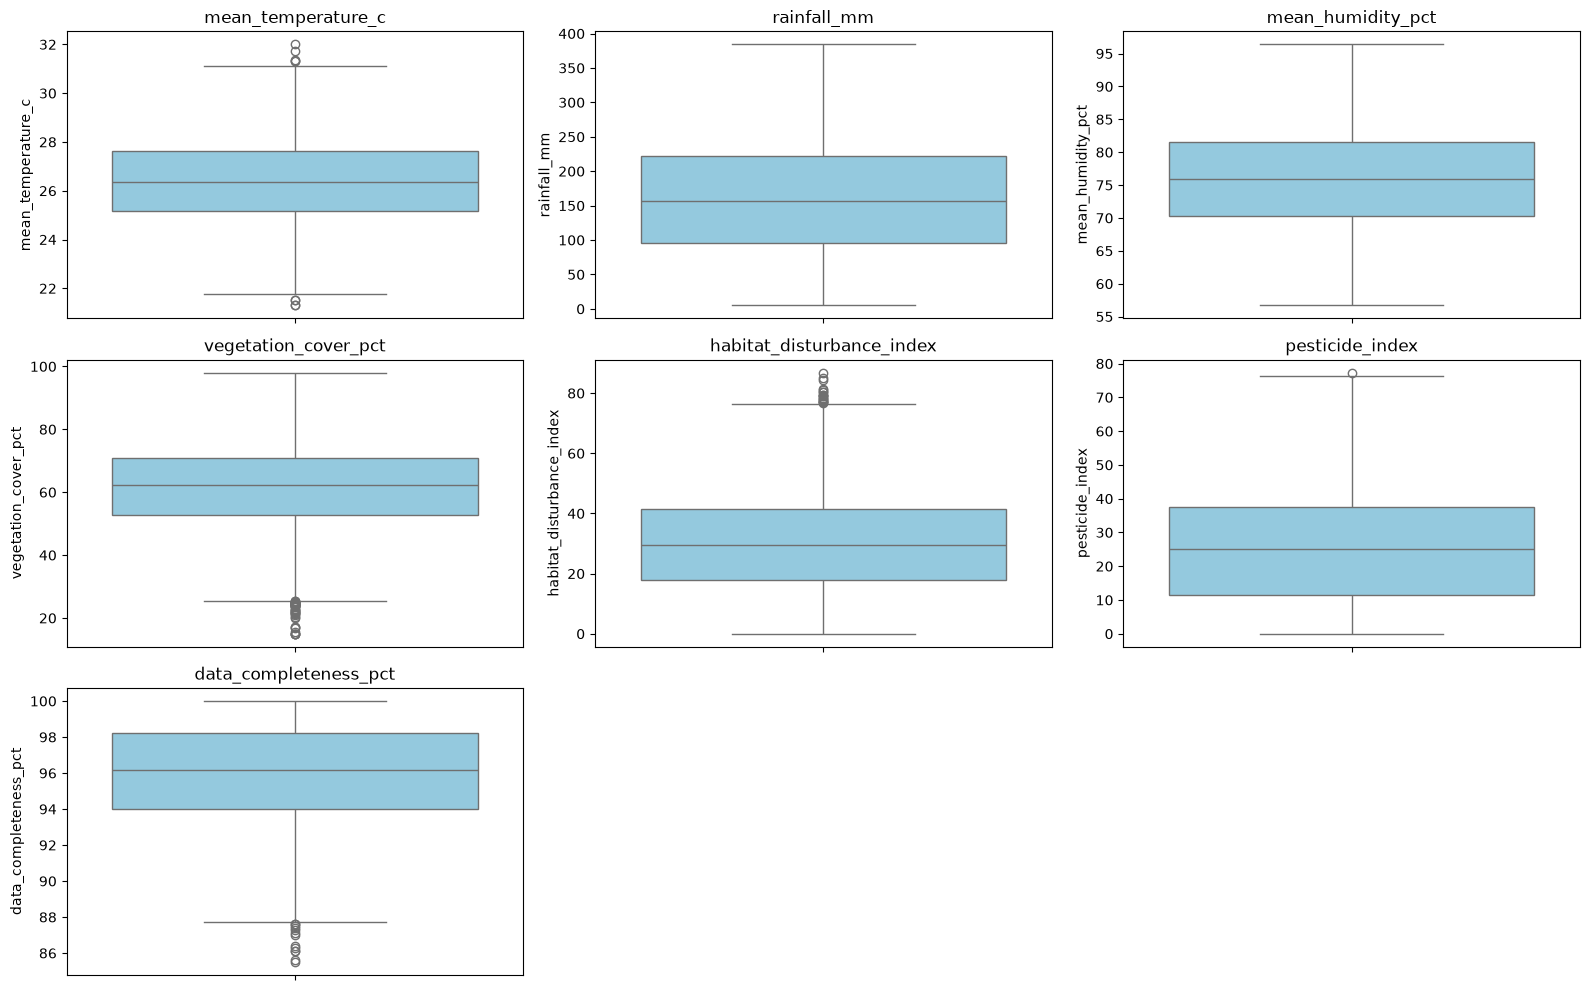

In [27]:
# Configuration de la taille globale de la figure
plt.figure(figsize=(16, 10))

for i, col in enumerate(cols_num, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df_stats[col], color="skyblue")
    plt.title(col)

plt.tight_layout()
plt.show()

Lecture des boxplots

rainfall_mm et mean_humidity_pct : aucun outlier détecté
mean_temperature_c : quelques valeurs extrêmes légères (autour de 22°C et 31-32°C)
vegetation_cover_pct : plusieurs sites avec une couverture végétale très basse (15-25%)
habitat_disturbance_index : plusieurs sites très perturbés (75-90)
pesticide_index : un seul point isolé très élevé (~77)

Vérification du point isolé de pesticide_index

En allant voir la ligne concernée, ce point appartient au site KNT-GKR (février 2024). En regardant l'historique complet de ce site, on constate qu'il oscille déjà régulièrement entre 12 et 77 sur plusieurs années (ex: 76.3 en octobre 2019, 73.2 en février 2020) — ce n'est donc pas une erreur isolée, mais un site naturellement très variable.

Décision : on garde tous les outliers. Aucune valeur n'est physiquement impossible, et elles sont cohérentes avec l'historique de leur site respectif. Ce sont des réalités environnementales, pas des erreurs.

In [28]:
# Comptage des points hors moustaches (règle 1.5 * IQR)
for col in cols_num:
    q1, q3 = df_stats[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    bas, haut = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n = ((df_stats[col] < bas) | (df_stats[col] > haut)).sum()
    print(f"{col:28s} min={df_stats[col].min():7.1f} max={df_stats[col].max():7.1f} -> {n} points hors moustaches")

mean_temperature_c           min=   21.3 max=   32.0 -> 9 points hors moustaches
rainfall_mm                  min=    5.0 max=  384.3 -> 0 points hors moustaches
mean_humidity_pct            min=   56.7 max=   96.4 -> 0 points hors moustaches
vegetation_cover_pct         min=   15.0 max=   98.0 -> 46 points hors moustaches
habitat_disturbance_index    min=    0.0 max=   86.8 -> 19 points hors moustaches
pesticide_index              min=    0.0 max=   77.3 -> 1 points hors moustaches
data_completeness_pct        min=   85.5 max=  100.0 -> 13 points hors moustaches


### - Justification du traitement des outliers

- **Contrôle de plausibilité d'abord** : aucune valeur impossible n'a été trouvée (pas de négatif, pas de
code sentinelle type -99 / 999, pourcentages tous entre 0 et 100, températures entre 21 et 32 °C
cohérentes avec un climat tropical). Il n'y a donc pas d'outlier "erreur de saisie" à traiter comme
donnée manquante.

- **Décision** : les points extrêmes (mois très secs ou très pluvieux, sites très dégradés) sont
**conservés**. Ce sont des réalités environnementales, et pour plusieurs d'entre eux le jeu de données
les documente lui-même via `weather_exception_code`. Les supprimer reviendrait à effacer exactement
l'information la plus intéressante de l'étude (cf. cours : un outlier peut être une anomalie
intéressante à repérer).

# 7. Histogrammes et distributions

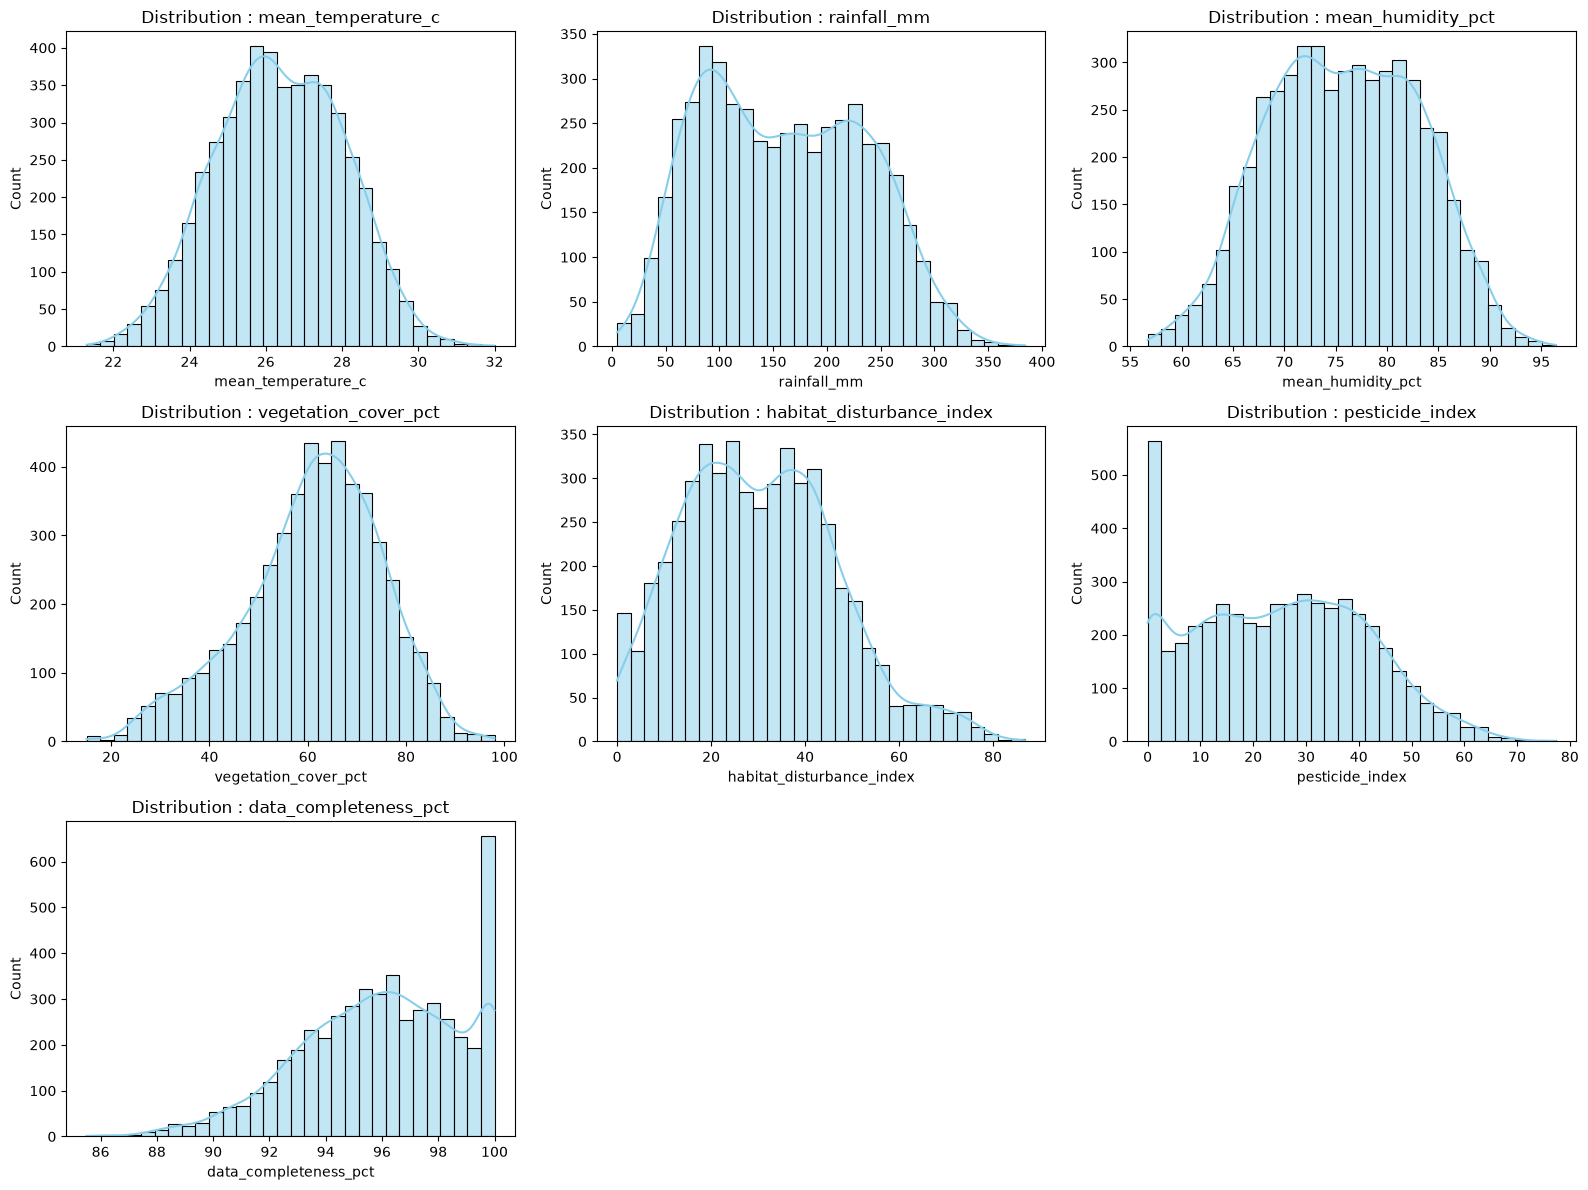

In [29]:
plt.figure(figsize=(16, 12))

for i, col in enumerate(cols_num, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df_stats[col], kde=True, bins=30, color='skyblue')
    plt.title(f"Distribution : {col}")

plt.tight_layout()
plt.show()

In [30]:
# Coefficients d'asymétrie (skewness) pour objectiver la forme des distributions
print(df_stats[cols_num].skew().round(2))

mean_temperature_c          -0.03
rainfall_mm                  0.18
mean_humidity_pct           -0.01
vegetation_cover_pct        -0.45
habitat_disturbance_index    0.40
pesticide_index              0.17
data_completeness_pct       -0.44
dtype: float64


### - Analyse exploratoire : distributions et lois statistiques

- **Proches d'une loi normale** : `mean_temperature_c`, `mean_humidity_pct` et `rainfall_mm` sont à peu près
symétriques autour de leur moyenne (asymétrie faible) — associer moyenne + écart-type a donc du sens.

- **Distributions asymétriques** : `vegetation_cover_pct` et `data_completeness_pct` sont étirées vers la
gauche (la plupart des sites/relevés sont bons, une minorité est très basse), tandis que
`habitat_disturbance_index` est étirée vers la droite (beaucoup de sites peu perturbés, une queue de
sites très dégradés). Pour ces variables, la **médiane + quartiles + min/max** décrit mieux la réalité
que la moyenne seule.

### - Répartition des variables catégorielles

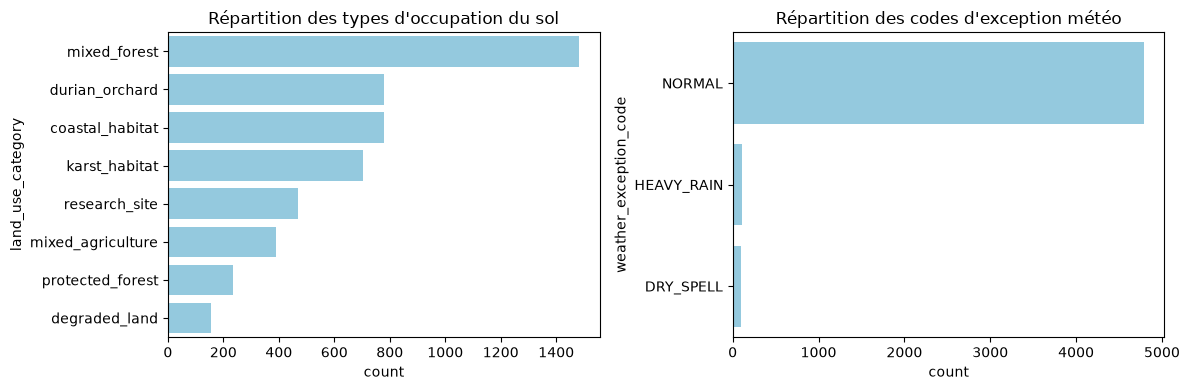

In [31]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.countplot(y='land_use_category', data=df_stats,
              order=df_stats['land_use_category'].value_counts().index, color='skyblue')
plt.title("Répartition des types d'occupation du sol")

plt.subplot(1, 2, 2)
sns.countplot(y='weather_exception_code', data=df_stats,
              order=df_stats['weather_exception_code'].value_counts().index, color='skyblue')
plt.title("Répartition des codes d'exception météo")

plt.tight_layout()
plt.show()

### - Saisonnalité (moyenne par mois calendaire)

,mean_temperature_c,rainfall_mm,mean_humidity_pct
month,,,
1,26.3,143.1,74.4
2,27.2,129.5,73.2
3,27.7,127.9,72.1
4,28.0,131.9,73.3
5,27.8,146.6,74.3
6,27.1,163.6,75.8
7,26.3,180.3,77.9
8,25.4,191.9,78.9
9,24.8,195.9,79.3


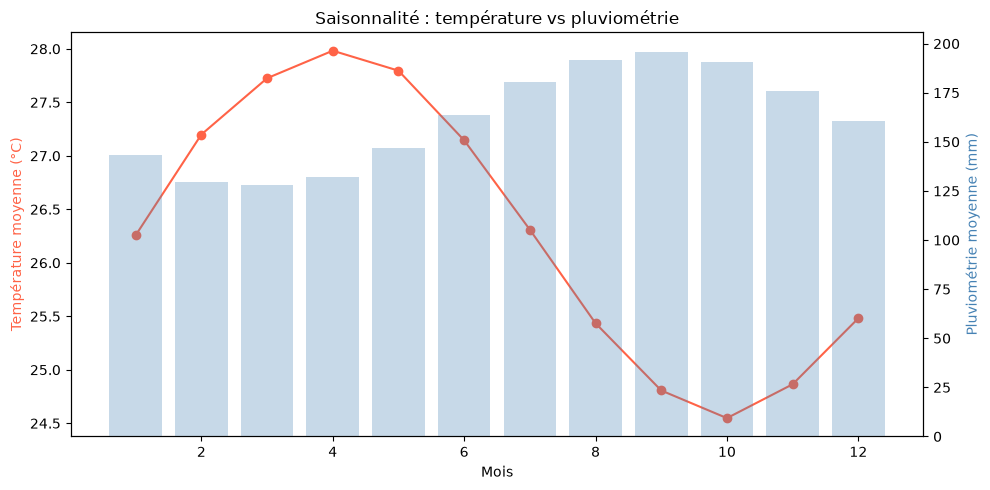

In [32]:
saison = df_stats.groupby('month')[['mean_temperature_c', 'rainfall_mm', 'mean_humidity_pct']].mean()
display(saison.round(1))

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(saison.index, saison['mean_temperature_c'], marker='o', color='tomato', label='Température (°C)')
ax1.set_xlabel("Mois")
ax1.set_ylabel("Température moyenne (°C)", color='tomato')

ax2 = ax1.twinx()
ax2.bar(saison.index, saison['rainfall_mm'], alpha=0.3, color='steelblue', label='Pluie (mm)')
ax2.set_ylabel("Pluviométrie moyenne (mm)", color='steelblue')

plt.title("Saisonnalité : température vs pluviométrie")
plt.tight_layout()
plt.show()

→ Signal clair de mousson : les mois les plus pluvieux (août–octobre) sont aussi les plus frais,
les mois secs (février–avril) les plus chauds. C'est cohérent avec un climat tropical et confirme que
les données ne sont pas aléatoires.

# 8. Corrélations

### Matrices de corrélation (Pearson + Spearman) sur les variables numériques

In [33]:
# 1. On calcule explicitement les DEUX méthodes distinctes
matrice_spearman = df_stats[cols_num].corr(method='spearman')
matrice_pearson = df_stats[cols_num].corr(method='pearson')

display(matrice_spearman.round(2))

,mean_temperature_c,rainfall_mm,mean_humidity_pct,vegetation_cover_pct,habitat_disturbance_index,pesticide_index,data_completeness_pct
mean_temperature_c,1.00,-0.22,-0.27,-0.06,0.00,-0.08,0.00
rainfall_mm,-0.22,1.00,0.75,0.34,0.01,0.08,-0.00
mean_humidity_pct,-0.27,0.75,1.00,0.27,0.01,-0.01,-0.02
vegetation_cover_pct,-0.06,0.34,0.27,1.00,-0.31,-0.04,0.02
habitat_disturbance_index,0.00,0.01,0.01,-0.31,1.00,0.05,0.00
pesticide_index,-0.08,0.08,-0.01,-0.04,0.05,1.00,0.00
data_completeness_pct,0.00,-0.00,-0.02,0.02,0.00,0.00,1.00


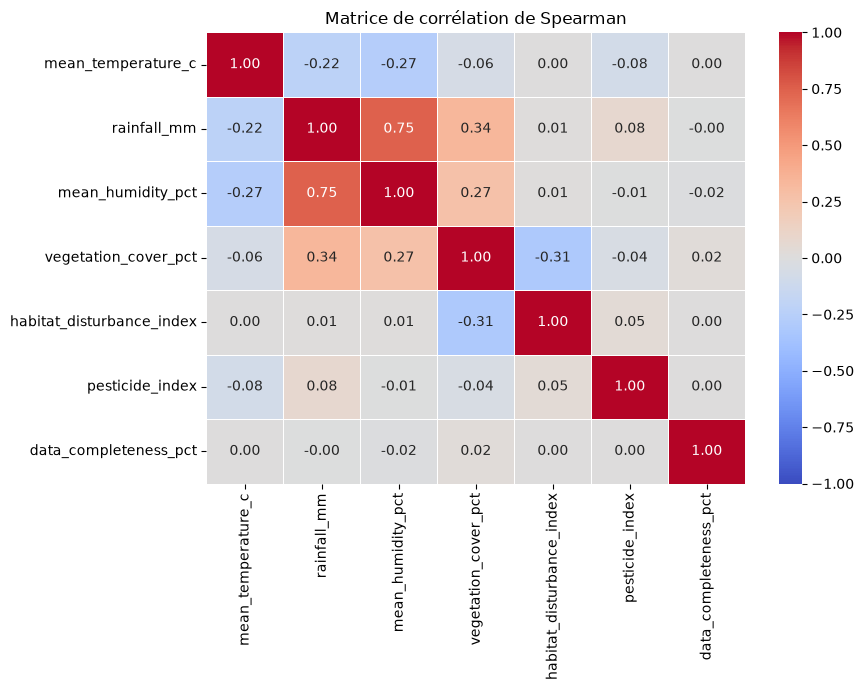

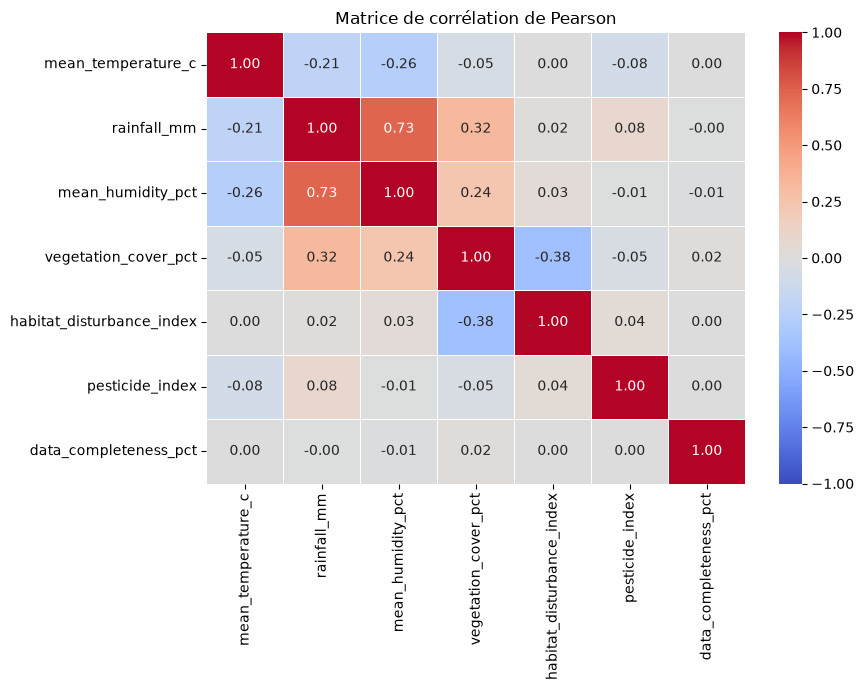

In [34]:
# Affichage de Spearman
plt.figure(figsize=(9, 7))
sns.heatmap(matrice_spearman, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
plt.title("Matrice de corrélation de Spearman")
plt.tight_layout()
plt.show()

# Affichage de Pearson
plt.figure(figsize=(9, 7))
sns.heatmap(matrice_pearson, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
plt.title("Matrice de corrélation de Pearson")
plt.tight_layout()
plt.show()

### Nuages de points croisés (Pairplot)

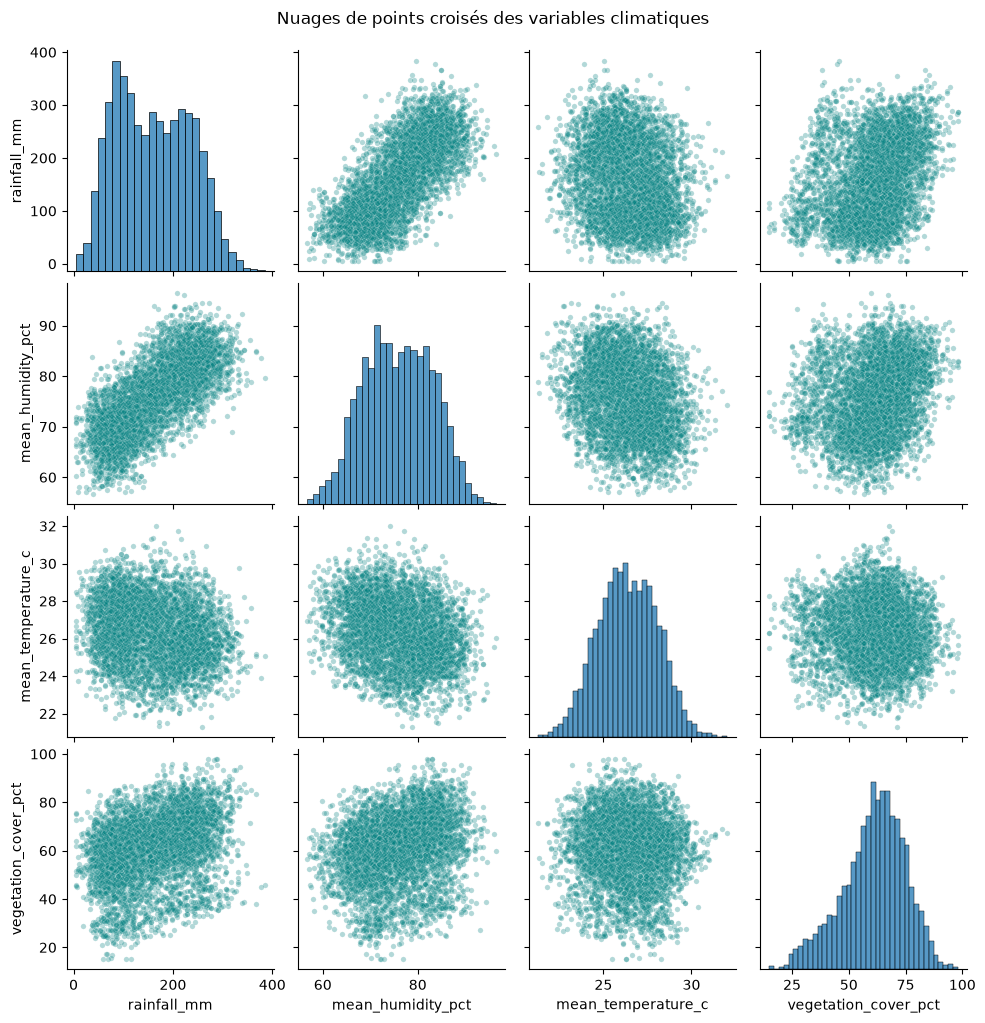

In [35]:
variables_a_croiser = ['rainfall_mm', 'mean_humidity_pct', 'mean_temperature_c', 'vegetation_cover_pct']

sns.pairplot(df_stats[variables_a_croiser], kind='scatter',
             plot_kws={'alpha': 0.3, 'color': 'teal', 's': 15})
plt.suptitle("Nuages de points croisés des variables climatiques", y=1.02)
plt.show()

### - Analyse des corrélations

- **pluie ↔ humidité (≈ 0.75)** : la corrélation la plus forte, relation monotone et quasi linéaire.
Les deux variables mesurent en partie le même phénomène → redondance à garder en tête si on construit
un modèle (colinéarité).
- **température ↔ pluie / humidité (≈ -0.22 / -0.27)** : négatif et modéré, c'est la saisonnalité vue plus haut.
- **couverture végétale ↔ perturbation de l'habitat (≈ -0.31)** : plus un site est perturbé, moins il est végétalisé.
Relation attendue écologiquement, mais **corrélation n'est pas causalité** : les deux peuvent découler
du même facteur (type d'occupation du sol).
- **`pesticide_index` et `data_completeness_pct`** ne sont corrélés à rien : `data_completeness_pct` est une
métadonnée de qualité de collecte, pas une mesure environnementale.
- **Pearson vs Spearman** donnent ici des valeurs très proches : les relations sont plutôt monotones et
linéaires, et il n'y a pas de queue de distribution extrême qui tire les coefficients (contrairement à des
données de comptage).

# 9. Export du jeu de données nettoyé

On exporte une seule version : nettoyée, mais **non encodée**. L'encodage One-Hot des catégorielles
sera fait plus tard, une seule fois, sur le jeu de données fusionné avec les 5 autres fichiers du lot.

In [36]:
df_stats.to_csv("environmental_monthly_clean.csv", index=False)

print("Dimensions finales :", df_stats.shape)
print("Valeurs manquantes restantes :", df_stats.isna().sum().sum())

Dimensions finales : (4992, 13)
Valeurs manquantes restantes : 0


# 10. Synthèse du nettoyage

| Problème identifié | Colonnes concernées | Traitement appliqué |
|---|---|---|
| Doublons stricts (2) et doublons de clé (site, mois) | toutes | suppression, on garde la 1ère occurrence |
| Date en texte | `reporting_month` | conversion en `datetime` + extraction `year` / `month` |
| Séparateur décimal virgule | températures, pluie, humidité | remplacement `,` → `.` |
| Unité collée à la valeur (`25.8 C`, `102.7 mm`) | `mean_temperature_c`, `rainfall_mm` | suppression du suffixe, une seule unité par colonne |
| Casse incohérente (18 catégories pour 8 réelles) | `land_use_category` | normalisation en minuscules |
| Manquants "porteurs de sens" (96%) | `weather_exception_code` | remplacés par la modalité `NORMAL` |
| Trous isolés dans les séries | `vegetation_cover_pct`, `pesticide_index` | interpolation temporelle **par site** |
| Valeurs extrêmes | variables numériques | **conservées** (réalités environnementales, pas des erreurs) |
| Encodage des catégorielles | `land_use_category`, `weather_exception_code` | **reporté** : fait une seule fois après le merge des 6 fichiers |

**Biais introduits et assumés** (cf. cours : nettoyer = choisir = introduire des biais) :
- l'interpolation invente 25 valeurs qui n'ont jamais été mesurées (0.3% du jeu, impact négligeable mais réel) ;
- en gardant la 1ère occurrence des doublons, on suppose que les deux lignes étaient identiques — ce qui a
été vérifié ici ;
- transformer l'absence de code météo en `NORMAL` suppose que le protocole de saisie était fiable : si un
opérateur a simplement oublié de remplir le champ un mois anormal, ce mois est désormais classé "normal".